In [6]:
from google.colab import files
import io
import pandas as pd
import re
import unicodedata
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import joblib
import warnings

warnings.filterwarnings('ignore')

print("Silakan klik 'Choose Files' untuk mengupload 'Dataset_JudiOnline_Tepat.csv':")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
print(f"\nFile '{file_name}' berhasil diunggah! Memproses data...")

df = pd.read_csv(io.BytesIO(uploaded[file_name]))
df = df.dropna(subset=['Comment', 'Final_Class'])

def clean_youtube_comment_fixed(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = unicodedata.normalize('NFKC', text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.strip()

df['Clean_Comment'] = df['Comment'].apply(clean_youtube_comment_fixed)

X_text = df['Clean_Comment']
y_label = df['Final_Class'].apply(lambda x: 1 if str(x).strip().upper() == 'P' else 0)

stopwords_id = ['yang', 'di', 'ke', 'dari', 'pada', 'dalam', 'untuk', 'dengan', 'dan', 'atau', 'ini', 'itu', 'juga', 'sudah', 'saya', 'dia', 'mereka', 'kita', 'kami', 'kamu', 'ada', 'tidak', 'bisa', 'akan', 'aku', 'buat', 'sama', 'yg', 'aja', 'nya', 'hari', 'banget', 'gue', 'gak', 'sih', 'coba', 'langsung', 'bikin', 'udah', 'emang']
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.8, stop_words=stopwords_id)

X = vectorizer.fit_transform(X_text)
y = y_label.values

print("\nMelatih model AI untuk Aplikasi...")
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X, y)
print("Pelatihan selesai!")

joblib.dump(vectorizer, 'judol_vectorizer.pkl')
joblib.dump(model, 'judol_model.pkl')

print("\nMenyiapkan file model untuk diunduh...")
files.download('judol_vectorizer.pkl')
files.download('judol_model.pkl')

Silakan klik 'Choose Files' untuk mengupload 'Dataset_JudiOnline_Tepat.csv':


Saving Dataset_JudiOnline_Tepat.csv to Dataset_JudiOnline_Tepat.csv

File 'Dataset_JudiOnline_Tepat.csv' berhasil diunggah! Memproses data...

Melatih model AI untuk Aplikasi...
Pelatihan selesai!

Menyiapkan file model untuk diunduh...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

=== HASIL EVALUASI MODEL (Threshold 0.85) ===
Accuracy  : 85.40%
Precision : 99.52%
Recall    : 68.26%
F1-Score  : 80.98%
----------------------------------------


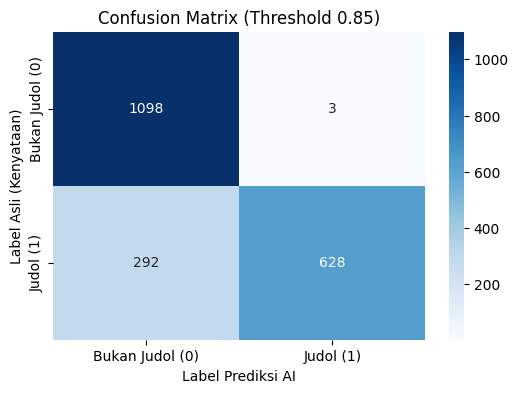


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Bukan Judol       0.79      1.00      0.88      1101
       Judol       1.00      0.68      0.81       920

    accuracy                           0.85      2021
   macro avg       0.89      0.84      0.85      2021
weighted avg       0.88      0.85      0.85      2021



In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y_label.values, test_size=0.2, random_state=42, stratify=y_label.values
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

model_eval = LogisticRegression(class_weight='balanced', max_iter=1000)
model_eval.fit(X_train, y_train)

THRESHOLD = 0.85
probabilities = model_eval.predict_proba(X_test)[:, 1]
y_pred_custom = (probabilities >= THRESHOLD).astype(int)

acc = accuracy_score(y_test, y_pred_custom)
prec = precision_score(y_test, y_pred_custom)
rec = recall_score(y_test, y_pred_custom)
f1 = f1_score(y_test, y_pred_custom)

print("=== HASIL EVALUASI MODEL (Threshold 0.85) ===")
print(f"Accuracy  : {acc * 100:.2f}%")
print(f"Precision : {prec * 100:.2f}%")
print(f"Recall    : {rec * 100:.2f}%")
print(f"F1-Score  : {f1 * 100:.2f}%")
print("-" * 40)

cm = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bukan Judol (0)', 'Judol (1)'],
            yticklabels=['Bukan Judol (0)', 'Judol (1)'])
plt.title(f'Confusion Matrix (Threshold {THRESHOLD})')
plt.ylabel('Label Asli (Kenyataan)')
plt.xlabel('Label Prediksi AI')
plt.show()

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_custom, target_names=['Bukan Judol', 'Judol']))

GRAFIK METRIK UNTUK PPT:


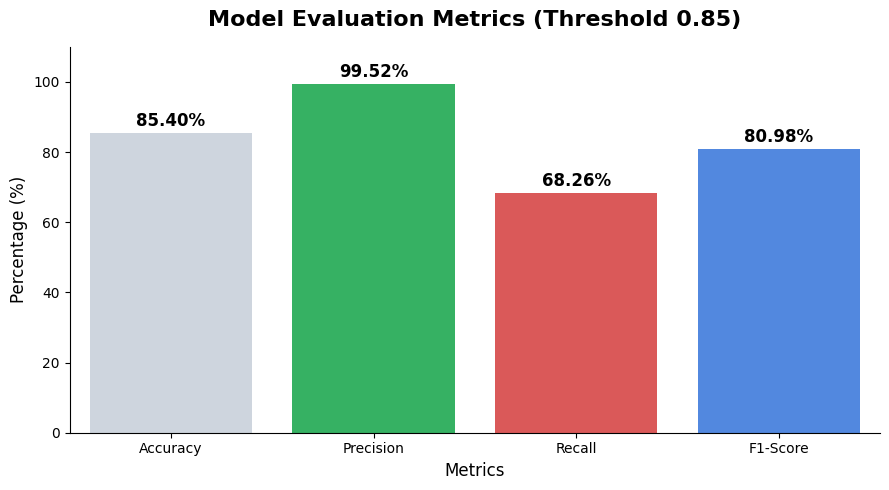


TABEL METRIK UNTUK PPT:


,Metrik Evaluasi,Nilai (%),Fokus Utama
0,Accuracy (Akurasi),85.40%,Kebenaran tebakan secara keseluruhan.
1,Precision (Ketepatan Blokir),99.52%,Sangat Tinggi: Minim pengguna normal yang jadi korban salah blokir.
2,Recall (Daya Tangkap),68.26%,Menengah: Mengorbankan sedikit komentar judol agar tidak salah tangkap.
3,F1-Score (Keseimbangan),80.98%,Rata-rata harmonis performa AI.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc * 100, prec * 100, rec * 100, f1 * 100]

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=metrics_names, y=metrics_values, palette=['#cbd5e1', '#22c55e', '#ef4444', '#3b82f6'])

plt.ylim(0, 110)
plt.title(f'Model Evaluation Metrics (Threshold {THRESHOLD})', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Metrics', fontsize=12)

for i, v in enumerate(metrics_values):
    ax.text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=12)

sns.despine()
plt.tight_layout()

print("GRAFIK METRIK UNTUK PPT:")
plt.show()

print("\nTABEL METRIK UNTUK PPT:")
data_tabel = {
    'Metrik Evaluasi': ['Accuracy (Akurasi)', 'Precision (Ketepatan Blokir)', 'Recall (Daya Tangkap)', 'F1-Score (Keseimbangan)'],
    'Nilai (%)': [f"{acc * 100:.2f}%", f"{prec * 100:.2f}%", f"{rec * 100:.2f}%", f"{f1 * 100:.2f}%"],
    'Fokus Utama': [
        'Kebenaran tebakan secara keseluruhan.',
        'Sangat Tinggi: Minim pengguna normal yang jadi korban salah blokir.',
        'Menengah: Mengorbankan sedikit komentar judol agar tidak salah tangkap.',
        'Rata-rata harmonis performa AI.'
    ]
}

df_metrics = pd.DataFrame(data_tabel)

styled_table = df_metrics.style.set_properties(**{
    'background-color': '#f8fafc',
    'color': 'black',
    'border-color': 'white',
    'text-align': 'left',
    'font-size': '14px'
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#005088'), ('color', 'white'), ('font-size', '15px'), ('text-align', 'left')]
}])

display(styled_table)